<div align="center">
  <h1><b> Quantum Computing </b></h1>
  <h2> Quantum Algorithms </h2>
  <h3> Grover's Algorithm </h3>
</div>

<br>
<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera">Lucas Camponogara Viera</a>

# Table of Contents

- [Theory](#theory)
- [Implementations](#implementations)
  - [Linear Search Algorithm](#linear-search-algorithm)
  - [Grover's Quantum Search Algorithm](#grovers-quantum-search-algorithm)
- [References](#references)

# Theory

![alt text](../../assets/grover.png)

© Image Credits: [QuCAI-Lab](https://github.com/qucai-lab).

Grover's algorithm is a quantum algorithm for unstructured search. It finds with $O(\sqrt{N})$ evaluations the solution to an input function $f : \sum^N \rightarrow \sum$, where $\sum = \{0,1\}$, satisfying $f(x) = 1$ for a binary string $x \in \sum^N$ and $f(x) = 0$ if the string $x$ is not a solution.

Unstructured Search Problem: Given a boolean function $f(x)$ and a set $\{x_1, x_2, \cdots, x_N \}$ of $N = 2^n$ unsorted items (binary strings), find a target item $x^*$ such that:

\begin{align}
    f(x) = 
    \begin{cases} 
      1 & \text{if } x = x^* \text{(target state)}. \\
      0 & \text{if } x \neq x^* \text{(not the target)}.
    \end{cases}
\end{align}




- [Linear Search](https://github.com/camponogaraviera/ds-and-algo/blob/main/theory/algorithms/searching/linear_search.md): $O(N)$ evaluations in the worst case.
  
- Grover's algorithm: $O(\sqrt{N})$ evaluations in the worst case.
  - **Time complexity**: Quadratic (polynomial) speedup of $O(\sqrt{N})$, not an exponential one.
  - **Source of speedup**: Quantum Parallelism.

![alt text](../../assets/grover_circuit.jpg)

© Image Credits: [Wikipedia](https://en.wikipedia.org/wiki/Grover%27s_algorithm).

## Initial Layer

To create a state of equal probability (hadamard state). Usually done by applying Hadamard gates to $n$ qubits initialized in the $|0\rangle$ state:

\begin{align}
    |h^n \rangle =: |h\rangle^{\otimes n} &= H^{\otimes n} |0^{\otimes n}\rangle = |+\rangle^{\otimes n} \\
    &=  \frac{1}{\sqrt{2^n}} \sum_{x=0}^{N -1 = 2^n-1} |x\rangle \\
    &= \frac{1}{\sqrt{N}} |x'\rangle + \frac{1}{\sqrt{N}} \sum_{x \neq x'}^{N -1} |x\rangle \\
    & = \frac{1}{\sqrt{N}} |x'\rangle + \sqrt{\frac{N-1}{N}} |x'_{\perp}\rangle \\
    &= \sin\theta|x'\rangle + \cos\theta |x'_{\perp}\rangle.
\end{align}

## Oracle

The Oracle is a problem-dependent unitary operation (quantum circuit) designed to mark one or more target (solution) states by inverting the sign of their probability amplitudes, i.e., performing a phase flip ($e^{i\pi} = -1$). The oracle is repeated $\frac{\pi \sqrt{N}}{4}$ times.

- The action of the Oracle represented by a unitary operator $U_w$ is given by:

\begin{align}
    U_w|x\rangle = (-1)^{f(x)}|x\rangle =
    \begin{cases} 
      -|x\rangle & \text{if } x = x^* \text{(target state), i.e., f(x) = 1 }. \\
      |x\rangle & \text{if } x \neq x^* \text{(not the target), i.e., f(x) = 0}.
    \end{cases}
\end{align}

- Alternative definition using an [ancilla qubit](https://en.wikipedia.org/wiki/Ancilla_bit) $|q\rangle$:

\begin{align}
    U_{f} |x\rangle |q\rangle = |x\rangle|q \oplus f(x)\rangle.
\end{align}

Where $\oplus$ denotes addition modulo 2.

One can see that the above definition is equivalent to the previous one by initializing the ancilla qubit in the $|-\rangle $ state:

\begin{align}
U_{f}|x\rangle|-\rangle & = U_{f}|x\rangle \Big( \frac{|0\rangle - |1\rangle}{\sqrt{2}} \Big) \\
& = \frac{1}{\sqrt{2}} \Big( U_{f}|x\rangle |0\rangle - U_{f}|x\rangle |1\rangle \Big) \\
& = \frac{1}{\sqrt{2}} \Big( |x\rangle |0\oplus f(x)\rangle - |x\rangle |1\oplus f(x)\rangle \Big) \\
& = \frac{1}{\sqrt{2}} \Big( |x\rangle |f(x)\rangle - |x\rangle |\bar{f(x)}\rangle \Big) \\
& = (-1)^{f(x)}|x\rangle |-\rangle.
\end{align}

### Oracle Design

The design of the Oracle is Problem-dependent.
  
1. Identify the target state(s) to be found.
2. Construct a unitary operation (quantum circuit) that flips the phase of only the target state(s).

## Diffuser Circuit

The goal of the diffuser circuit is to amplify the probability amplitude of the target state while decreasing the amplitudes of all other states. In other words, it applies a conditional phase shift to all states except the initial state $|\psi_0^n\rangle$. This is usually achieved through a series of rotations by repeating the same diffuser circuit $\frac{\pi \sqrt{N}}{4}$ times.

\begin{align}
    U_d = 2 |h^n \rangle \langle h^n| - I_N.
\end{align}

## Grover's Circuit

To obtain the Grover's circuit, we repeat the following two steps:

1. Initialize the qubits to the equal superposition state $|h^n\rangle$.
   
2. Repeat the following steps $\frac{\pi \sqrt{N}}{4}$ times:
    - 2.1 Apply the Oracle $U_w$ to mark the target state(s).
    - 2.2 Apply the Diffuser $U_d$ to amplify the probability amplitude of the marked state(s).

3. Measure the qubits to obtain the result.

The overall operation of Grover's algorithm can be expressed as:

\begin{align}
U_d U_w |h\rangle &= \cdots
\end{align}

# Implementations

## Linear Search Algorithm

In [ ]:
def linear_search(arr, target):
    """
    Performs linear search to find the target in the array.
    Time Complexity: O(N).

    Args:
        - arr (list): list of elements to search.
        - target (any): element to search for.

    Returns:
        - index of target if found, else -1.
    """

    for index in range(len(arr)):
        print(f"Iteration {index + 1}.")
        if arr[index] == target:
            print(f"Element found at index {index}!")
            return index
        
    print("Element not found!")
    return -1


In [53]:
numbers = [2*i for i in range(10)] # Even numbers from 0 to 18.
target = numbers[-1] # Last element in the list.

print(f"Searching for {target} in the list: {numbers}:\n")
result = linear_search(numbers, target)

Searching for 18 in the list: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]:

Iteration 1.
Iteration 2.
Iteration 3.
Iteration 4.
Iteration 5.
Iteration 6.
Iteration 7.
Iteration 8.
Iteration 9.
Iteration 10.
Element found at index 9!


## Grover's Quantum Search Algorithm

In [1]:
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from itertools import product

### Helper Functions

In [ ]:
def GetCounts(qc):
    """
    Function to get counts from the circuit simulation.
    
    Args:
        qc (QuantumCircuit): The quantum circuit to simulate.

    Returns:
        dict: Measurement results as counts.
    """
    backend = Aer.get_backend('qasm_simulator') # Using QASM simulator backend to get measurement counts.
    job = backend.run(qc, shots=1024)
    result = job.result()
    counts = result.get_counts(qc)
    print("Measurement results:", counts)
    return counts

### Oracle Design

In [3]:
def Oracle(marked_states, qc):
    '''
    Oracle circuit to mark the given states by flipping their phase.
    Code snippet borrowed from [1].

    Args:
        marked_states (list or str): List of bitstrings to be marked or a single bitstring.
        qc (QuantumCircuit): The quantum circuit to apply the oracle on.

    Returns:
        QuantumCircuit: The quantum circuit with the oracle applied.
    '''
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
        
    num_qubits = len(marked_states[0])

    for target in marked_states:
        rev_target = target[::-1]
        zero_inds = [
            ind
            for ind in range(num_qubits)
            if rev_target.startswith("0", ind)
        ]
        if zero_inds:
            qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        if zero_inds:
            qc.x(zero_inds)
    return qc

Oracle for target state |00⟩


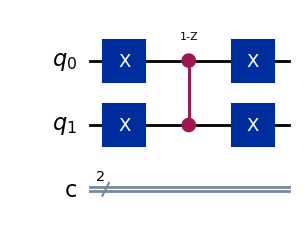

Oracle for target state |01⟩


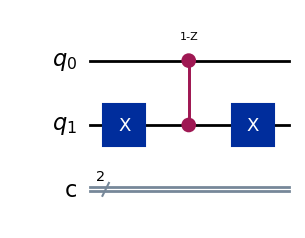

Oracle for target state |10⟩


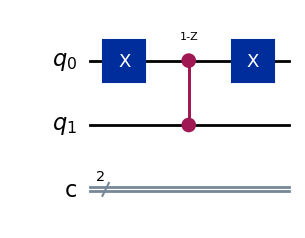

Oracle for target state |11⟩


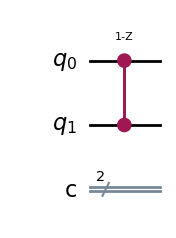

In [4]:
bitstrings = [''.join(bits) for bits in product('01', repeat=2)]

for target_state in bitstrings:
    qc = QuantumCircuit(2, 2)
    Oracle([target_state], qc)
    print(f"Oracle for target state |{target_state}⟩")
    display(qc.draw(output="mpl", style="iqp"))

### Diffuser Circuit

In [5]:
def Diffuser(qc):
    """
    Diffuser circuit to amplify the amplitude of the marked state.
    
    Args:
        qc (QuantumCircuit): The quantum circuit to apply the diffuser on.
    """
    qc.h([0,1])
    qc.z([0,1])
    qc.cz(0,1)
    qc.h([0,1])

### Grover Simulation

- Single Target State:

Grover for target state |00⟩:


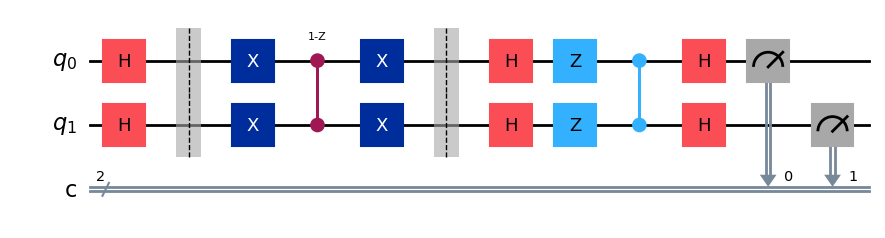

Measurement results: {'00': 1024}


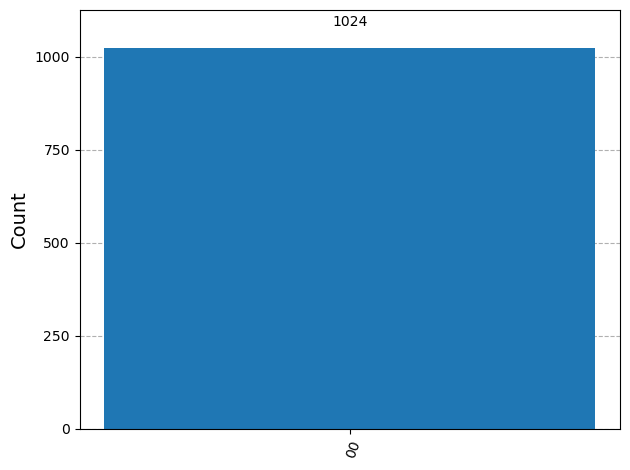

Grover for target state |01⟩:


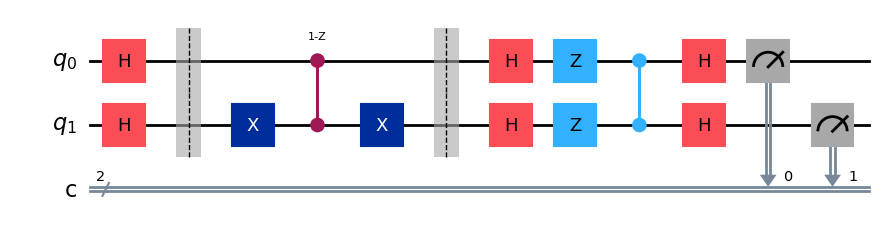

Measurement results: {'01': 1024}


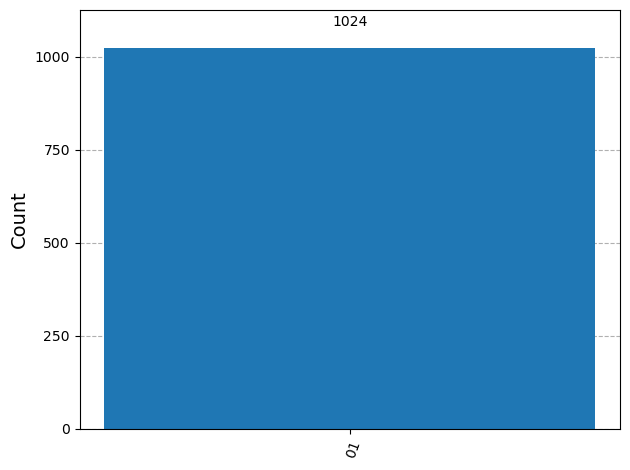

Grover for target state |10⟩:


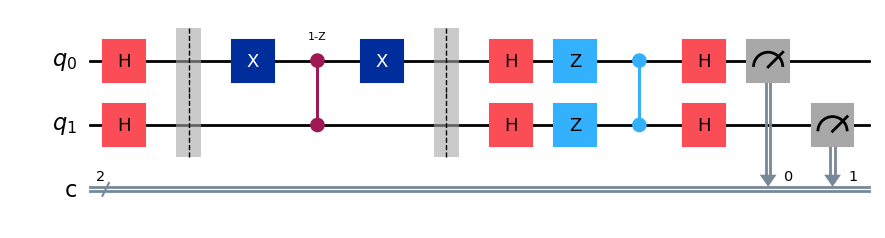

Measurement results: {'10': 1024}


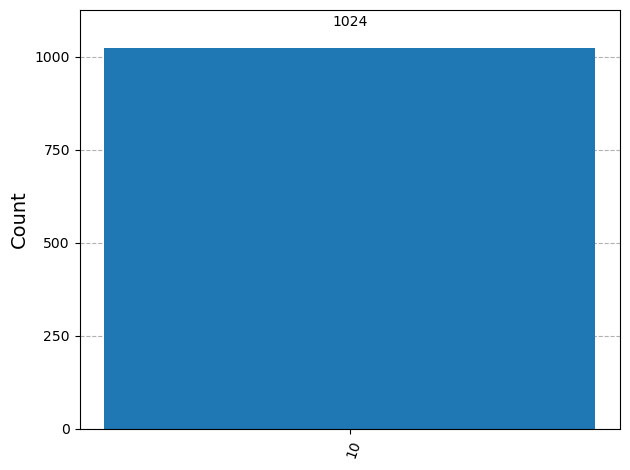

Grover for target state |11⟩:


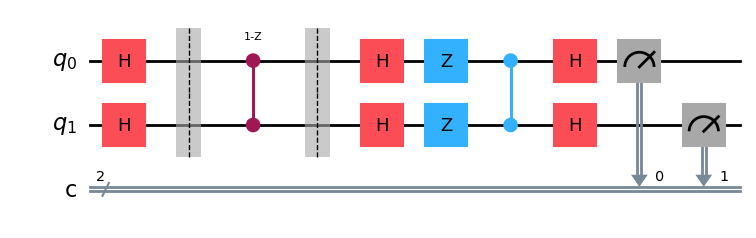

Measurement results: {'11': 1024}


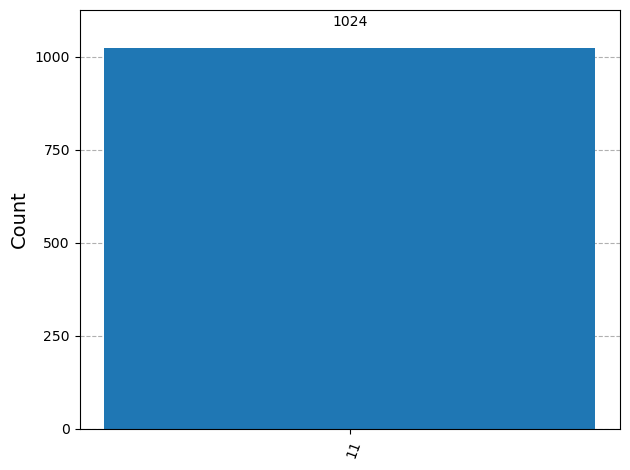

In [12]:
for target_state in bitstrings:
    qc = QuantumCircuit(2, 2)
    qc.h([0, 1])         
    qc.barrier()    
    Oracle([target_state], qc) 
    qc.barrier()
    Diffuser(qc)         
    qc.measure([0, 1], [0, 1]) # qc.measure([q0, q1], [c0, c1]).
    print(f"Grover for target state |{target_state}⟩:")
    display(qc.draw(output="mpl", style="iqp"))

    counts = GetCounts(qc.decompose())
    display(plot_histogram(counts))


- Multiple Target States:

Grover for target states ['01', '10']:


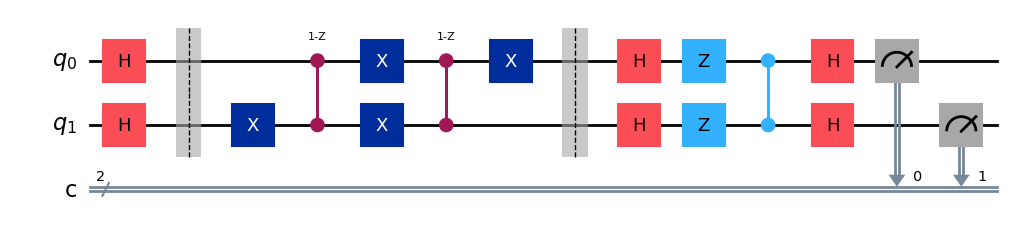

Measurement results: {'11': 250, '10': 274, '00': 236, '01': 264}


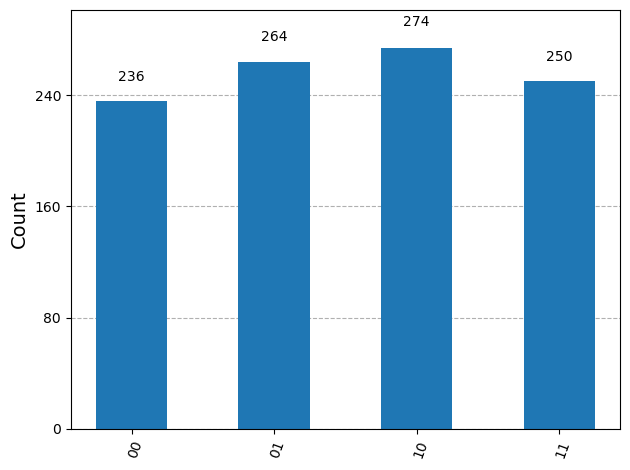

In [15]:
target_states = ["01", "10"]

qc = QuantumCircuit(2, 2)
qc.h([0, 1])         
qc.barrier()    
Oracle(target_states, qc) 
qc.barrier()
Diffuser(qc)         
qc.measure([0, 1], [0, 1]) # qc.measure([q0, q1], [c0, c1]).
print(f"Grover for target states {target_states}:")
display(qc.draw(output="mpl", style="iqp"))

counts = GetCounts(qc.decompose())
display(plot_histogram(counts))

# References

[1] https://quantum.cloud.ibm.com/docs/en/tutorials/grovers-algorithm